## Data Exploration and Preprocessing

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("single_genre_artists.csv")
pd.set_option("display.max_columns", None)
df['release_date'] = pd.to_numeric(df['release_date'], errors='coerce')

df.head(5)


,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922.0,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922.0,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922.0,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924.0,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924.0,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [2]:
df.shape

(95837, 23)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        21494 non-null  float64
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [4]:
df.isnull().sum() # no null values

id_songs                  0
name_song                 0
popularity_songs          0
duration_ms               0
explicit                  0
id_artists                0
release_date          74343
danceability              0
energy                    0
key                       0
loudness                  0
mode                      0
speechiness               0
acousticness              0
instrumentalness          0
liveness                  0
valence                   0
tempo                     0
time_signature            0
followers                 0
genres                    0
name_artists              0
popularity_artists        0
dtype: int64

In [5]:
df.duplicated().sum() # No duplicates

np.int64(0)

In [6]:
df = df.drop({"id_songs","name_song","id_artists","name_artists"},axis=1)
df.head(5)

,popularity_songs,duration_ms,explicit,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,popularity_artists
0,0,161427,0,1922.0,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],22
1,0,223440,0,1922.0,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],22
2,0,208267,0,1922.0,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],22
3,0,161933,0,1924.0,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],22
4,0,167973,0,1924.0,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],22


## Data Distribution and Normalization

In [7]:
df.keys()

Index(['popularity_songs', 'duration_ms', 'explicit', 'release_date',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'time_signature', 'followers', 'genres', 'popularity_artists'],
      dtype='object')

In [8]:
print(df["explicit"].unique()) # binary
print("-------------------------------")
print(df["mode"].unique()) # binary
print("-------------------------------")
print(df["key"].unique())
print("-------------------------------")

[0 1]
-------------------------------
[1 0]
-------------------------------
[ 4 10  0  9  1  5  2  7  3  8  6 11]
-------------------------------


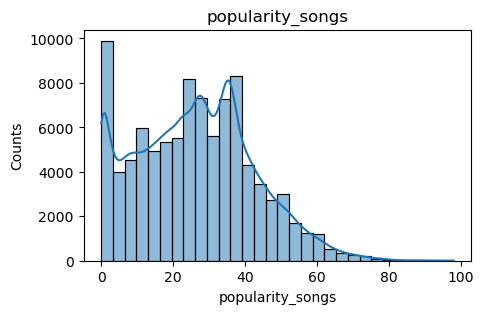

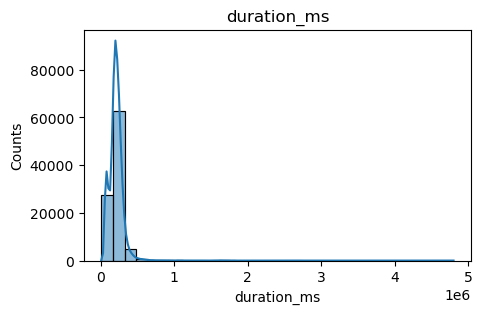

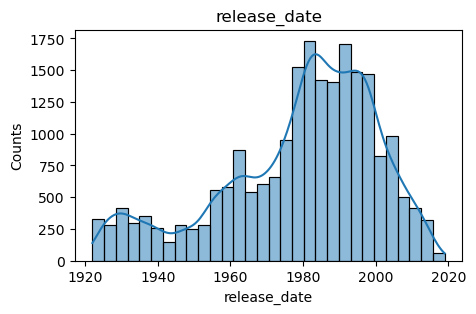

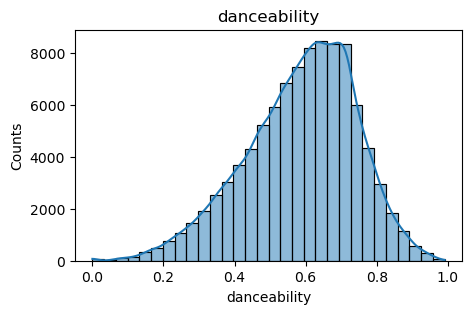

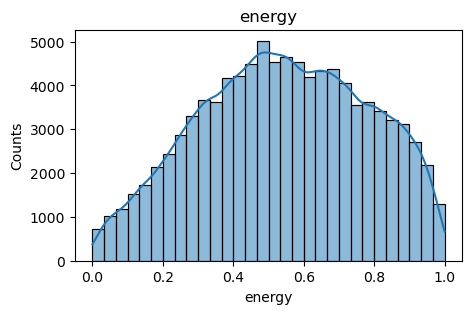

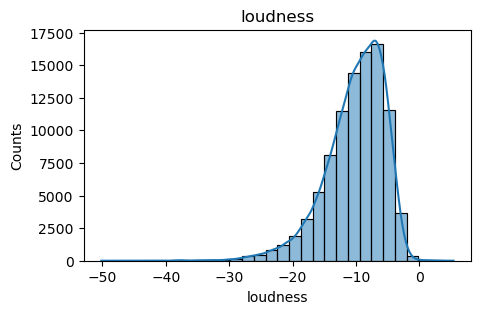

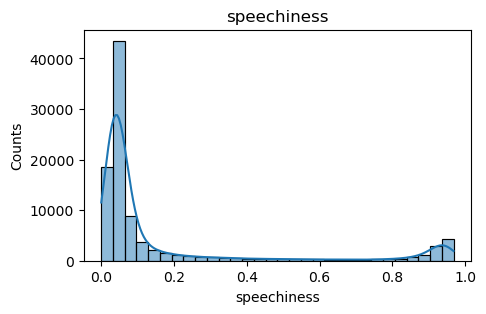

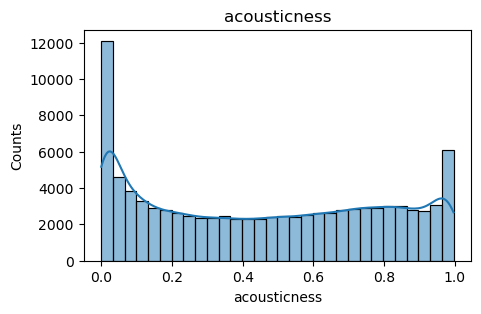

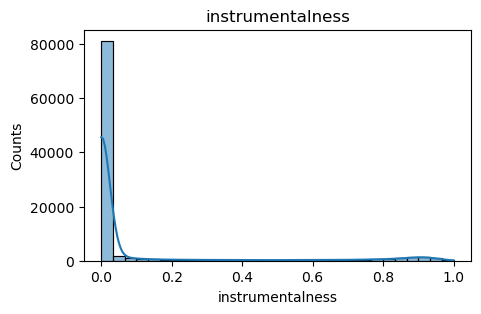

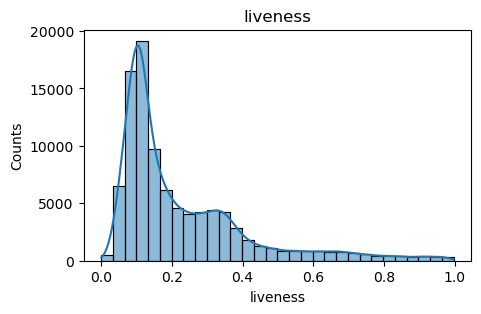

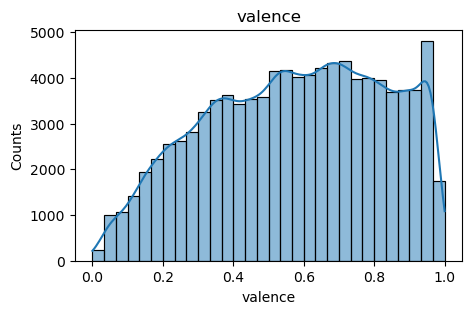

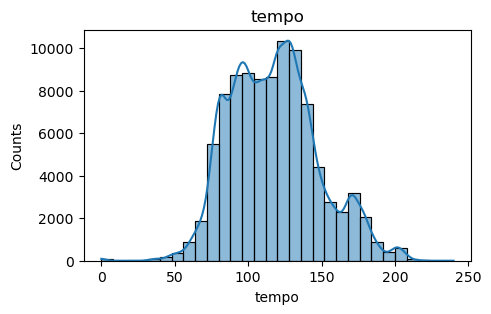

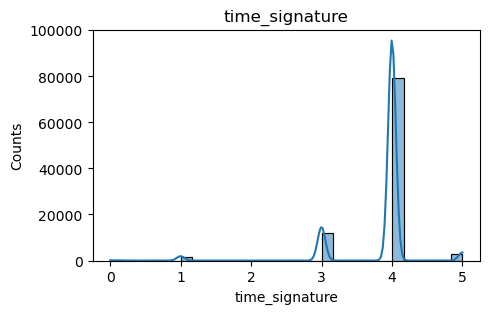

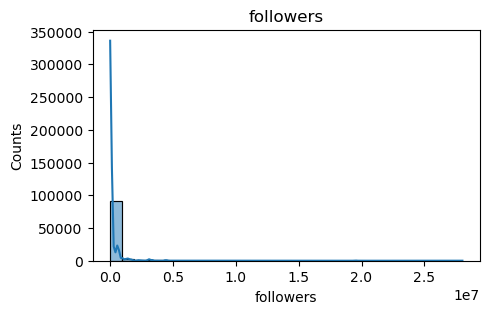

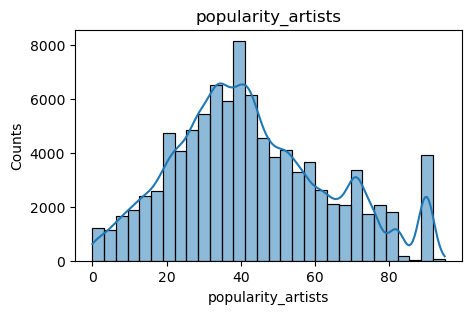

popularity_songs       0.269680
duration_ms           10.035801
release_date          -0.809319
danceability          -0.476795
energy                -0.108657
loudness              -1.119249
speechiness            2.128985
acousticness           0.087552
instrumentalness       2.863243
liveness               1.768667
valence               -0.208343
tempo                  0.353626
time_signature        -2.853088
followers             15.785259
popularity_artists     0.388150
dtype: float64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

label = ['popularity_songs', 'duration_ms', 'release_date',
       'danceability', 'energy', 'loudness', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'time_signature', 'followers', 'popularity_artists']

for col in label:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], bins=30, kde=True)   # seaborn histogram
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Counts")
    plt.show()

df[label].skew(numeric_only=True)


### from the data it is veryclear that 
- duration_ms,followers - high positive skew
- speechiness,instrumentalness,liveness - small positive skew
- time_signature,loudness - small negative skew
- other are in acceptable skew range distribution

In [10]:
# standard scaller works fine for k-means

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

columns = ['popularity_songs', 'duration_ms', 'release_date',
           'danceability', 'energy', 'loudness', 'speechiness',
           'acousticness', 'instrumentalness', 'liveness',
           'valence', 'tempo', 'time_signature',
           'followers', 'popularity_artists']

df[columns] = scaler.fit_transform(df[columns])

df.head()


,popularity_songs,duration_ms,explicit,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,popularity_artists
0,-1.603686,-0.401735,0,-2.649656,-0.153476,-1.511128,4,-0.757909,1,-0.427109,1.616187,-0.353338,0.538584,0.321287,0.515005,-1.563846,-0.247089,['vintage chanson'],-0.996249
1,-1.603686,0.124906,0,-2.649656,-1.028518,-1.528056,10,-1.098629,1,-0.369741,1.604081,-0.353405,-0.521537,-0.577455,-1.294487,-1.563846,-0.247089,['vintage chanson'],-0.996249
2,-1.603686,-0.003949,0,-2.649656,-0.488051,-1.418027,0,-1.127899,1,-0.398062,1.622240,-0.353405,1.039046,-0.375943,-1.560003,0.273029,-0.247089,['vintage chanson'],-0.996249
3,-1.603686,-0.397437,0,-2.556861,0.573581,-0.313510,9,-0.470677,0,-0.013914,1.610134,-0.353405,-0.031836,0.611464,0.405268,0.273029,-0.247089,['vintage chanson'],-0.996249
4,-1.603686,-0.346143,0,-2.556861,0.406294,-1.028695,9,-0.768227,1,-0.111948,1.610134,-0.353405,0.796887,1.087031,-1.377593,0.273029,-0.247089,['vintage chanson'],-0.996249


### Feature selection and Clustering

In [11]:
df.keys()

Index(['popularity_songs', 'duration_ms', 'explicit', 'release_date',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'time_signature', 'followers', 'genres', 'popularity_artists'],
      dtype='object')

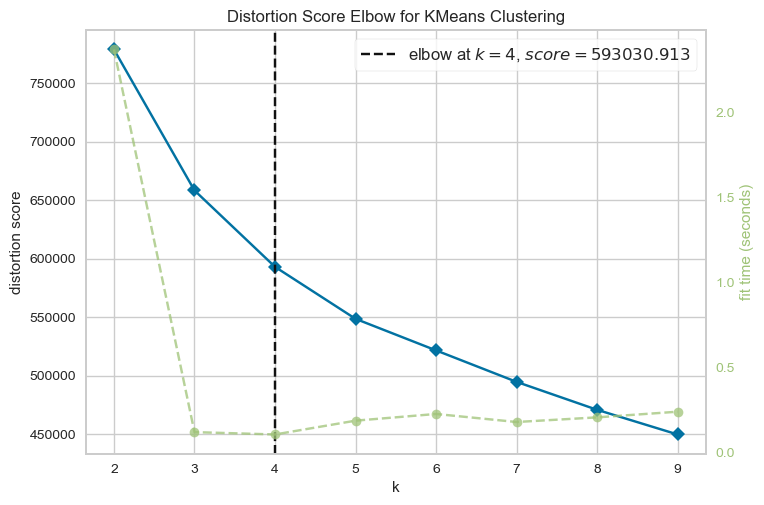

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [12]:
import pandas as pd
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

data = df[["danceability", "energy", "loudness", "speechiness",
           "acousticness", "instrumentalness", "liveness",
           "valence", "tempo", "duration_ms"]]


model = KMeans(random_state=42)

visualizer = KElbowVisualizer(model, k=(2, 10))

visualizer.fit(data)

visualizer.show()

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

data = df[["danceability", "energy", "loudness", "speechiness",
           "acousticness", "instrumentalness", "liveness",
           "valence", "tempo", "duration_ms"]]


model = KMeans(n_clusters=4, random_state=42)
model.fit(data)

df['Group'] = model.labels_

sil_score = silhouette_score(data, model.labels_)
print("Silhouette Score:", sil_score)

# Inertia (within-cluster sum of squares)
print("Inertia:", model.inertia_)


Silhouette Score: 0.23106641264473862
Inertia: 593031.089426731


In [14]:
from sklearn.metrics import davies_bouldin_score # Tells how well the clusters are seperated from eachother

dbs = davies_bouldin_score(data, model.labels_)
print("Davies-Bouldin Index:", dbs)


Davies-Bouldin Index: 1.5296828507168276


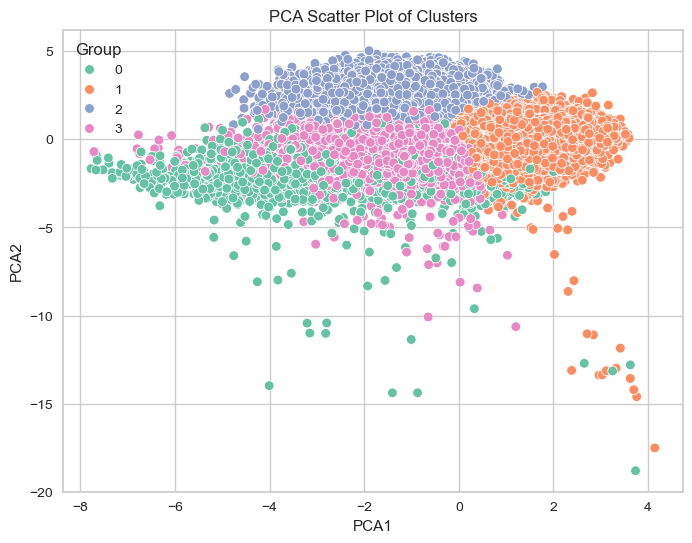

In [22]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=3)
pca_data = pca.fit_transform(data)

# Add PCA components to dataframe
df['PCA1'] = pca_data[:,0]
df['PCA2'] = pca_data[:,1]

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Group', data=df, palette='Set2')
plt.title("PCA Scatter Plot of Clusters")
plt.show()


C:\Users\SAM\AppData\Local\Temp\ipykernel_25596\615555028.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Group', data=df, palette='Set2')


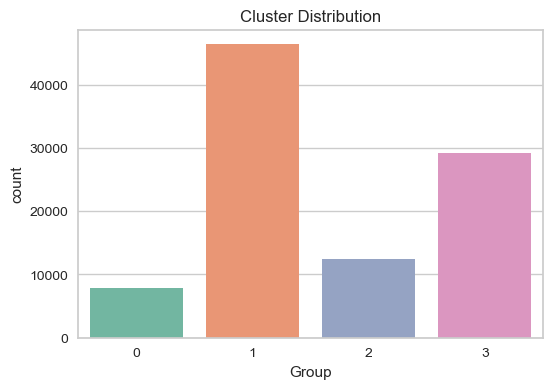

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='Group', data=df, palette='Set2')
plt.title("Cluster Distribution")
plt.show()